In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

In [52]:
file_path = 'data_rsl.csv'
df = pd.read_csv(file_path, dtype=str)

print(df.shape)
df.head()

(206, 22)


,участник,мама,папа,сестра,брат,родители,тетя,дядя,внучка,внук,бабушка,дедушка,сын,дочь,возраст,возраст_категория,город,город_категория,город_центр,пол,пол_категория,(non)Native
0,2,1,1,1,1,1,1,1,дактиль,дактиль,1,1,1,1,41,1,Санкт-Петербург,2,0,men,0,0
1,3,1,1,2,2,1,2,2,1+дактиль,1+2,1,2,1,4,17,0,Москва,6,1,men,0,0
2,6,2,1,4,1,1,2,1,1+2,3,1,1,1,4,26,1,Санкт-Петербург,2,0,men,0,0
3,7,1,1,2,2,1,4,2,дактиль,дактиль,1,1,1,4,34,1,Иваново,1,1,men,0,0
4,8,1,1,2,2,1+2+3,2,2,дактиль,дактиль,1,2,2,2,33,1,Сочи,3,0,men,0,0


# Описательный анализ

In [53]:
kinship_terms = [
    'мама', 'папа', 'сестра', 'брат', 'родители',
    'тетя', 'дядя', 'внучка', 'внук',
    'бабушка', 'дедушка', 'сын', 'дочь'
]

factors = [
    'пол',
    'возраст_категория',
    'город_категория',
    '(non)Native'
]

In [54]:
# удаляем варианты, которые встречаются менее 2 раз

df_filtered = df.copy()

for term in kinship_terms:
    counts = df_filtered[term].value_counts()
    keep = counts[counts >= 2].index
    df_filtered.loc[~df_filtered[term].isin(keep), term] = pd.NA

df = df_filtered

In [55]:
def get_term_frequencies(df, term):
    counts = df[term].value_counts(dropna=True)
    percentages = (counts / counts.sum() * 100).round(2)

    result = pd.DataFrame({
        'count': counts,
        'percent': percentages
    })

    return result.sort_values('count', ascending=False)

get_term_frequencies(df, 'папа')

,count,percent
папа,,
1,170,85.86
3,18,9.09
2,10,5.05


In [56]:
def analyze_term(df, term, factor, normalize=False):
    table = pd.crosstab(
        df[term],
        df[factor],
        normalize='columns' if normalize else False
    )

    if normalize:
        table = (table * 100).round(1)

    return table

analyze_term(df, 'дочь', 'город_категория')

город_категория,1,2,3,4,5,6
дочь,,,,,,
1,8,1,0,1,2,22
2,13,1,4,6,15,8
3,1,0,0,0,1,1
4,14,9,9,8,16,19
5,0,1,0,1,1,0
6,0,0,0,2,0,1
9,2,0,0,0,1,3


In [57]:
def most_common_variant_by_factor(df, term, factor):
    result = (
        df.groupby(factor)[term]
        .agg(lambda x: x.value_counts().idxmax())
        .reset_index(name='наиболее_частотный_вариант')
    )
    return result

most_common_variant_by_factor(df, 'дедушка', 'город_категория')

,город_категория,наиболее_частотный_вариант
0,1,1
1,2,1
2,3,7
3,4,1
4,5,1
5,6,1


# Тест хи-квадрат

In [59]:
import scipy
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['дочь'], df['город_категория'])
chi2, p, dof, expected = chi2_contingency(contingency)

print(f'chi2 = {chi2:.3f}')
print(f'p-value = {p:.5f}')
print(f'dof = {dof}')

# p < 0.05 - распределение вариантов статистически связано с фактором.
# p >= 0.05 - статистически значимой связи не обнаружено.

chi2 = 55.917
p-value = 0.00279
dof = 30


In [31]:
def test_term_vs_factors(df, term, factors):
    results = []

    for factor in factors:
        contingency = pd.crosstab(df[term], df[factor])

        if contingency.shape[0] > 1 and contingency.shape[1] > 1:
            chi2, p, dof, expected = chi2_contingency(contingency)
            results.append({
                'термин': term,
                'фактор': factor,
                'chi2': chi2,
                'p_value': p,
                'dof': dof,
                'значимо': p < 0.05
            })

    return pd.DataFrame(results).sort_values('p_value')

results= test_term_vs_factors(df, 'родители', factors)
print(results)

     термин             фактор       chi2   p_value  dof  значимо
2  родители    город_категория  47.166156  0.023970   30     True
1  родители  возраст_категория   5.299252  0.506044    6    False
3  родители        (non)Native   5.025915  0.540494    6    False
0  родители                пол   4.233263  0.645143    6    False


# Построение графиков

In [46]:
def quick_plot(df, term, factor):
    data = df[[term, factor]].dropna()
    data[term] = data[term].astype(str).str.strip()

    if factor == '(non)Native':
        data[factor] = data[factor].map({'0': 'non-Native', '1': 'Native'})

    elif factor == 'город_категория':
        data[factor] = data[factor].map({
            '1': 'Центральный',
            '2': 'Северо-Западный',
            '3': 'Южный',
            '4': 'Поволжье и Урал',
            '5': 'Сибирь и Дальний Восток',
            '6': 'Москва'
        })
        order = ['Москва', 'Центральный', 'Северо-Западный', 'Поволжье и Урал',
                 'Сибирь и Дальний Восток', 'Южный']
        data[factor] = pd.Categorical(data[factor], categories=order, ordered=True)

    hue_order = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'дактиль']

    present_gestures = data[term].unique()
    digits = sorted([g for g in present_gestures if g.isdigit()], key=int)
    non_digits = sorted([g for g in present_gestures if not g.isdigit()])
    hue_order = digits + non_digits
    hue_order=hue_order

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.countplot(data=data, x=factor, hue=term, hue_order=hue_order, edgecolor='black', palette='Set3', ax=ax)

    labels = [l.get_text().replace('.0', '') for l in ax.get_xticklabels()]
    ax.set_xticklabels(labels, fontsize=9)


    labels = [l.get_text().replace('.0', '') for l in ax.get_xticklabels()]
    ax.set_xticklabels(labels)

    legend1 = ax.legend(bbox_to_anchor=(0.845, 0.99), loc='upper left', title="Вариант жеста")
    ax.add_artist(legend1)

    ax.set_ylabel("Количество респондентов", fontsize=14)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_5756/3540753714.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, fontsize=9)
/tmp/ipykernel_5756/3540753714.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


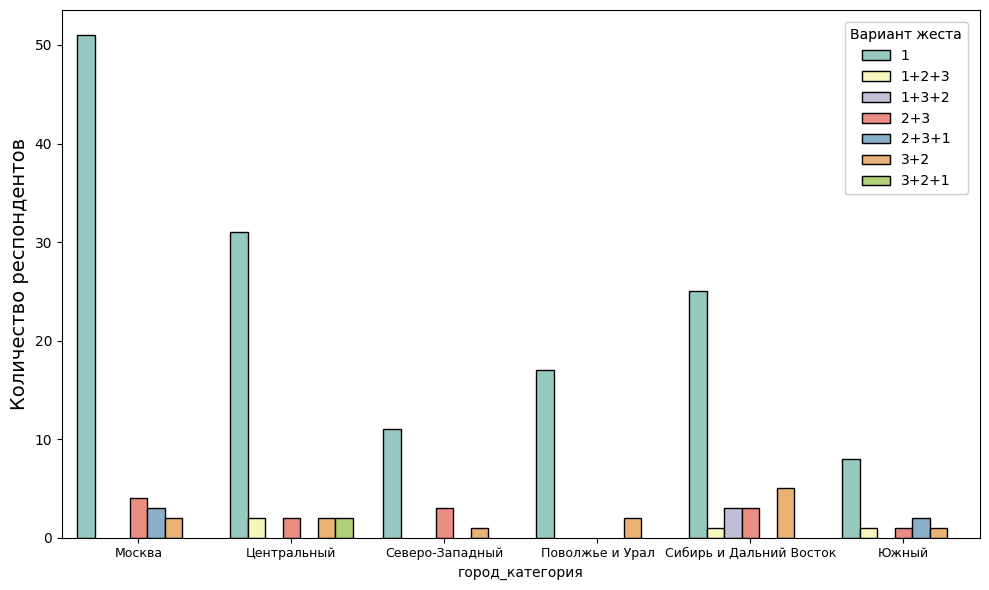

In [47]:
quick_plot(df, 'родители', 'город_категория')

# Точный тест Фишера

In [35]:
all_results = []

for term in kinship_terms:
    res = test_term_vs_factors(df, term, factors)
    all_results.append(res)

all_results = pd.concat(all_results, ignore_index=True)
all_results = all_results.sort_values('p_value')

all_results.head(20)

,термин,фактор,chi2,p_value,dof,значимо
24,дядя,город_категория,99.079374,2.593622e-09,30,True
20,тетя,город_категория,79.017568,1.625274e-07,25,True
44,сын,город_категория,49.136701,3.844884e-07,10,True
40,дедушка,город_категория,76.328601,4.243047e-07,25,True
8,сестра,город_категория,61.397071,4.319459e-06,20,True
45,сын,пол,14.877518,5.880145e-04,2,True
28,внучка,(non)Native,27.632741,1.098354e-03,9,True
4,папа,город_категория,29.133693,1.185428e-03,10,True
0,мама,(non)Native,13.318321,1.282222e-03,2,True
32,внук,(non)Native,26.435760,1.732989e-03,9,True


In [48]:
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests


def find_significant_y_for_x(
    df,
    x_col,
    y_col,
    alpha=0.05,
    min_count=2,
    min_lift=1.0,
    correction_scope="per_x",
):
    """
    Для каждого x_i ищет y_j, которые встречаются с ним чаще, чем ожидалось случайно.

    df: датафрейм с парами x-y
    x_col: название колонки с x
    y_col: название колонки с y
    alpha: уровень значимости
    min_count: минимальное число наблюдений пары x-y
    min_lift: минимальный lift
    correction_scope:
        "per_x"  — поправка на множественные проверки отдельно внутри каждого x
        "global" — поправка на все пары сразу
    """

    data = df[[x_col, y_col]].dropna().copy()
    ct = pd.crosstab(data[x_col], data[y_col])

    N = ct.values.sum()

    x_totals = ct.sum(axis=1)
    y_totals = ct.sum(axis=0)

    rows = []

    for x in ct.index:
        n_x = x_totals.loc[x]

        for y in ct.columns:
            observed = ct.loc[x, y]

            if observed == 0:
                continue

            n_y = y_totals.loc[y]
            expected = n_x * n_y / N

            p_value = hypergeom.sf(observed - 1, N, n_y, n_x)

            lift = observed / expected if expected > 0 else np.nan

            residual = (
                (observed - expected) / np.sqrt(expected)
                if expected > 0
                else np.nan
            )

            rows.append({
                x_col: x,
                y_col: y,
                "observed": observed,
                "expected": expected,
                "lift": lift,
                "residual": residual,
                "p_value": p_value,
                "x_total": n_x,
                "y_total": n_y,
                "x_share": observed / n_x,
                "global_y_share": n_y / N,
            })

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    if correction_scope == "global":
        result["p_value_adj"] = multipletests(
            result["p_value"],
            method="fdr_bh"
        )[1]

    elif correction_scope == "per_x":
        result["p_value_adj"] = np.nan

        for x, idx in result.groupby(x_col).groups.items():
            result.loc[idx, "p_value_adj"] = multipletests(
                result.loc[idx, "p_value"],
                method="fdr_bh"
            )[1]

    else:
        raise ValueError("correction_scope должен быть 'per_x' или 'global'")

    result["significant"] = (
        (result["p_value_adj"] < alpha)
        & (result["observed"] >= min_count)
        & (result["lift"] >= min_lift)
    )

    result = result.sort_values(
        [x_col, "significant", "p_value_adj", "lift"],
        ascending=[True, False, True, False]
    )

    return result

In [49]:
x = find_significant_y_for_x(df, 'дядя', 'город_категория')
x[x['significant'] == True]

,дядя,город_категория,observed,expected,lift,residual,p_value,x_total,y_total,x_share,global_y_share,p_value_adj,significant
1,1,2,9,1.490446,6.038462,6.151146,2.190774e-07,18,13,0.500000,0.082803,8.763098e-07,True
9,2,6,40,31.509554,1.269456,1.512549,2.126810e-03,97,51,0.412371,0.324841,1.276086e-02,True
20,6,5,4,0.815287,4.906250,3.527079,1.476231e-03,4,32,1.000000,0.203822,1.476231e-03,True
